# Duration distribution comparison

Compare generated duration and speed plots for the full dataset and the dataset without station-continuity discontinuities.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Could not find project root containing Data/")


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "Data"
PRESENTATION_DIR = PROJECT_ROOT / "notebooks" / "04_data_presentation"

if str(PRESENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(PRESENTATION_DIR))

import duration_plot_utils as dpu


## ---------- Dataset configuration ----------


In [2]:
DATASETS = {
    "Pełny zbiór": DATA_DIR / "final_trip_data.parquet",
    "Bez nieciągłości": DATA_DIR / "rides_data_without_discontinuities.parquet",
}

lower_limit = 3
upper_limit = 180
selected_duration_range_label = f"{lower_limit}-{upper_limit} min"
full_duration_range_label = "pełny dodatni zakres czasu"
a_values = [1.5, 1.75, 2]
speed_a_values = [1.5, 1.75, 2]

DATASETS


{'Pełny zbiór': PosixPath('/Users/artur/Studia/Rowerki/Data/final_trip_data.parquet'),
 'Bez nieciągłości': PosixPath('/Users/artur/Studia/Rowerki/Data/rides_data_without_discontinuities.parquet')}

## ---------- Preparing outputs for both datasets ----------


In [3]:
outputs_by_dataset = {}

for dataset_name, data_file in DATASETS.items():
    print("=" * 80)
    print(dataset_name)
    print(data_file)

    outputs_by_dataset[dataset_name] = dpu.prepare_dataset_outputs(
        data_file,
        lower_limit=lower_limit,
        upper_limit=upper_limit,
        a_values=a_values,
        speed_a_values=speed_a_values,
    )


Pełny zbiór
/Users/artur/Studia/Rowerki/Data/final_trip_data.parquet
Liczba przejazdów w zakresie 3-180 min: 16655915
Liczba wszystkich przejazdów: 17426293
Udział danych w tym zakresie: 95.58%

a = 1.5
Number of bins: 11
First bin edges: [ 3.      4.5     6.75   10.125  15.1875]
Last bin edges: [ 51.2578125   76.88671875 115.33007812 172.99511719 180.        ]

a = 1.75
Number of bins: 8
First bin edges: [ 3.          5.25        9.1875     16.078125   28.13671875]
Last bin edges: [ 28.13671875  49.23925781  86.16870117 150.79522705 180.        ]

a = 2
Number of bins: 6
First bin edges: [ 3  6 12 24 48]
Last bin edges: [ 12  24  48  96 180]
Liczba przejazdów w zakresie 3-180 min z policzoną prędkością: 16223608

a = 1.5
Number of bins: 24
First bin edges: [0.00527694 0.00791541 0.01187312 0.01780968 0.02671452]
Last bin edges: [17.54718795 26.32078193 39.4811729  59.22175935 68.40017186]

a = 1.75
Number of bins: 17
First bin edges: [0.00527694 0.00923465 0.01616064 0.02828111 0.0494

In [4]:
comparison_summary = dpu.comparison_summary(outputs_by_dataset)
comparison_summary


,dataset,liczba_wszystkich_przejazdow,liczba_przejazdow_w_zakresie,udzial_w_zakresie_%,liczba_przejazdow_z_predkoscia,min_speed_km_h,max_speed_km_h
0,Pełny zbiór,17426293,16655915,95.579220,16223608,0.005277,68.400172
1,Bez nieciągłości,16091818,15377692,95.562179,14977630,0.005277,68.400172


## ---------- Para 1: zakres czasu 3-180 min ----------


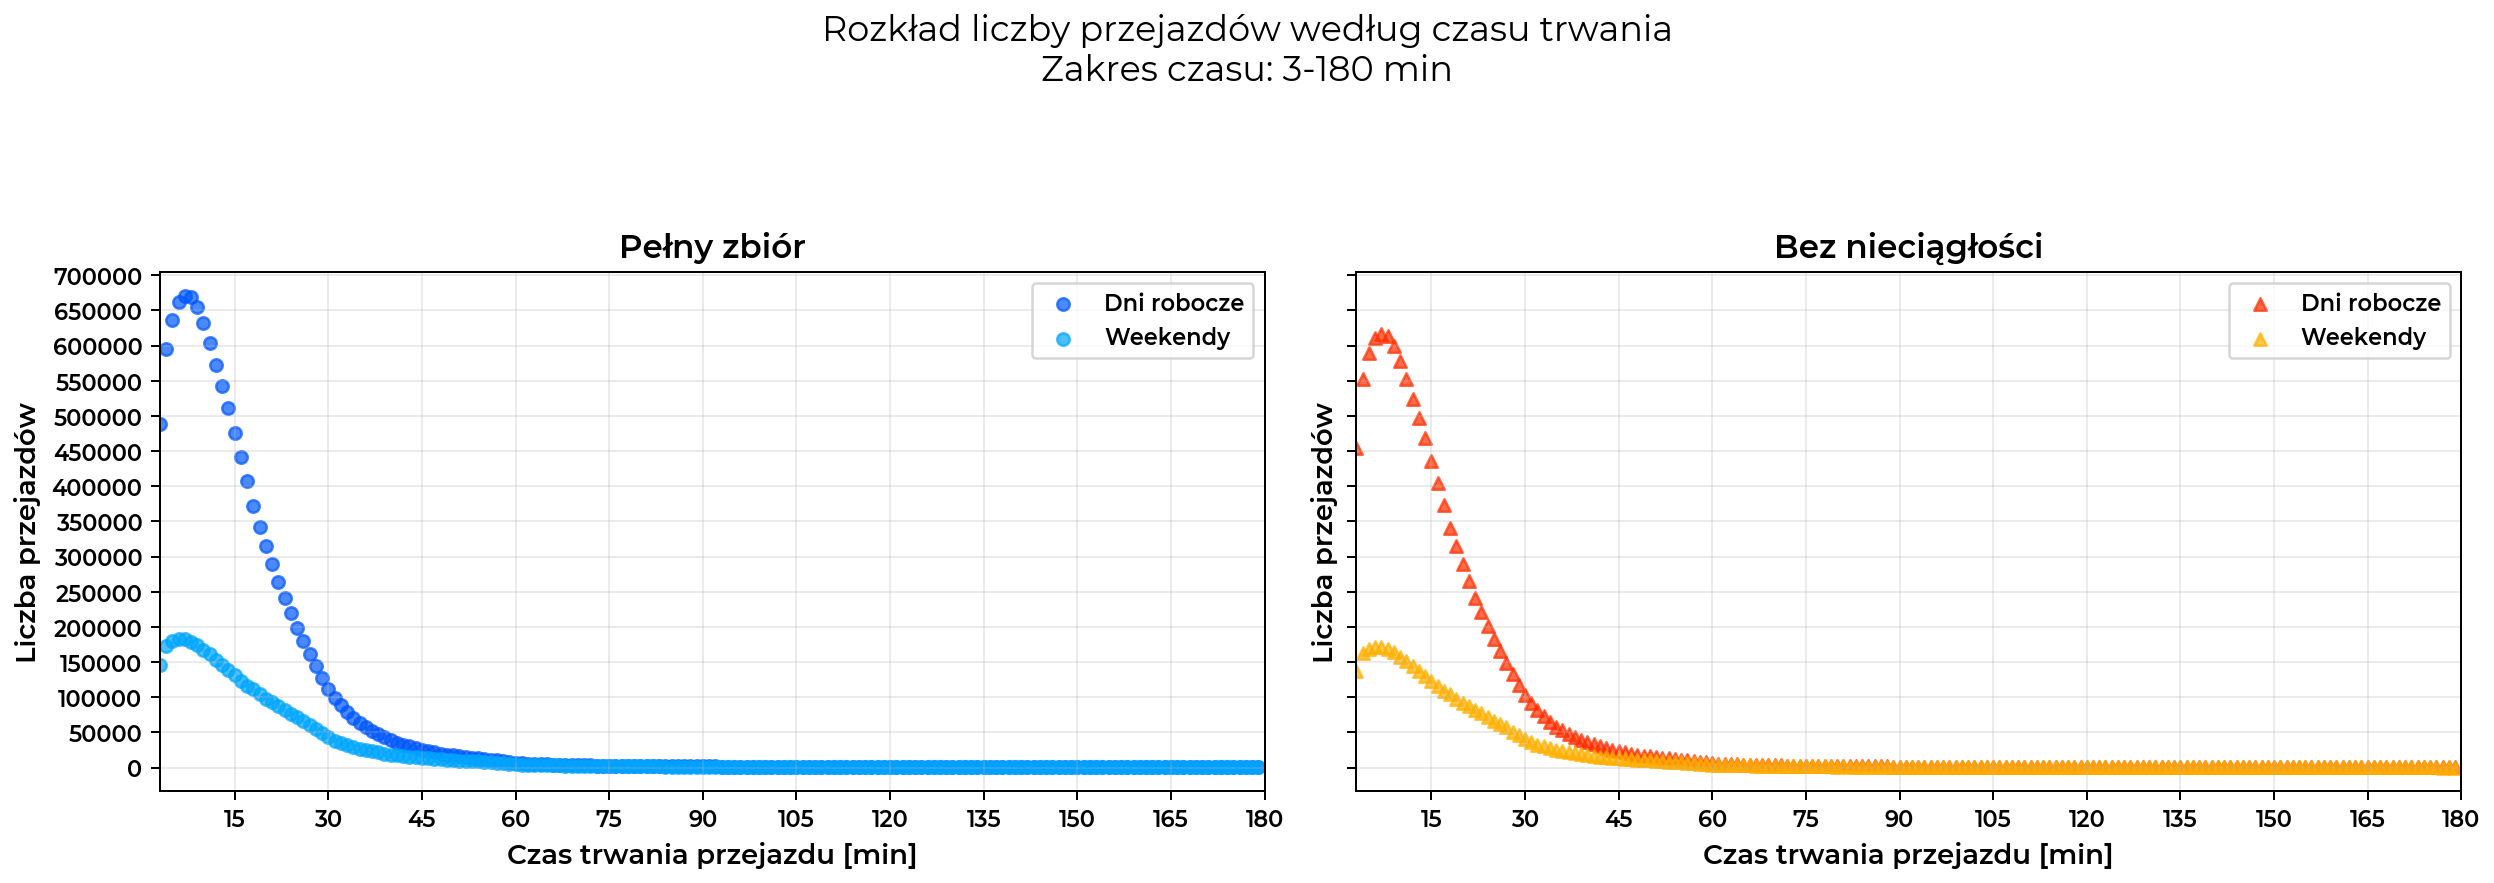

In [5]:
# ---------- Duration counts: weekdays vs weekends ----------

fig, axes = dpu.plot_duration_counts_dataset_comparison(
    outputs_by_dataset,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)
plt.show()


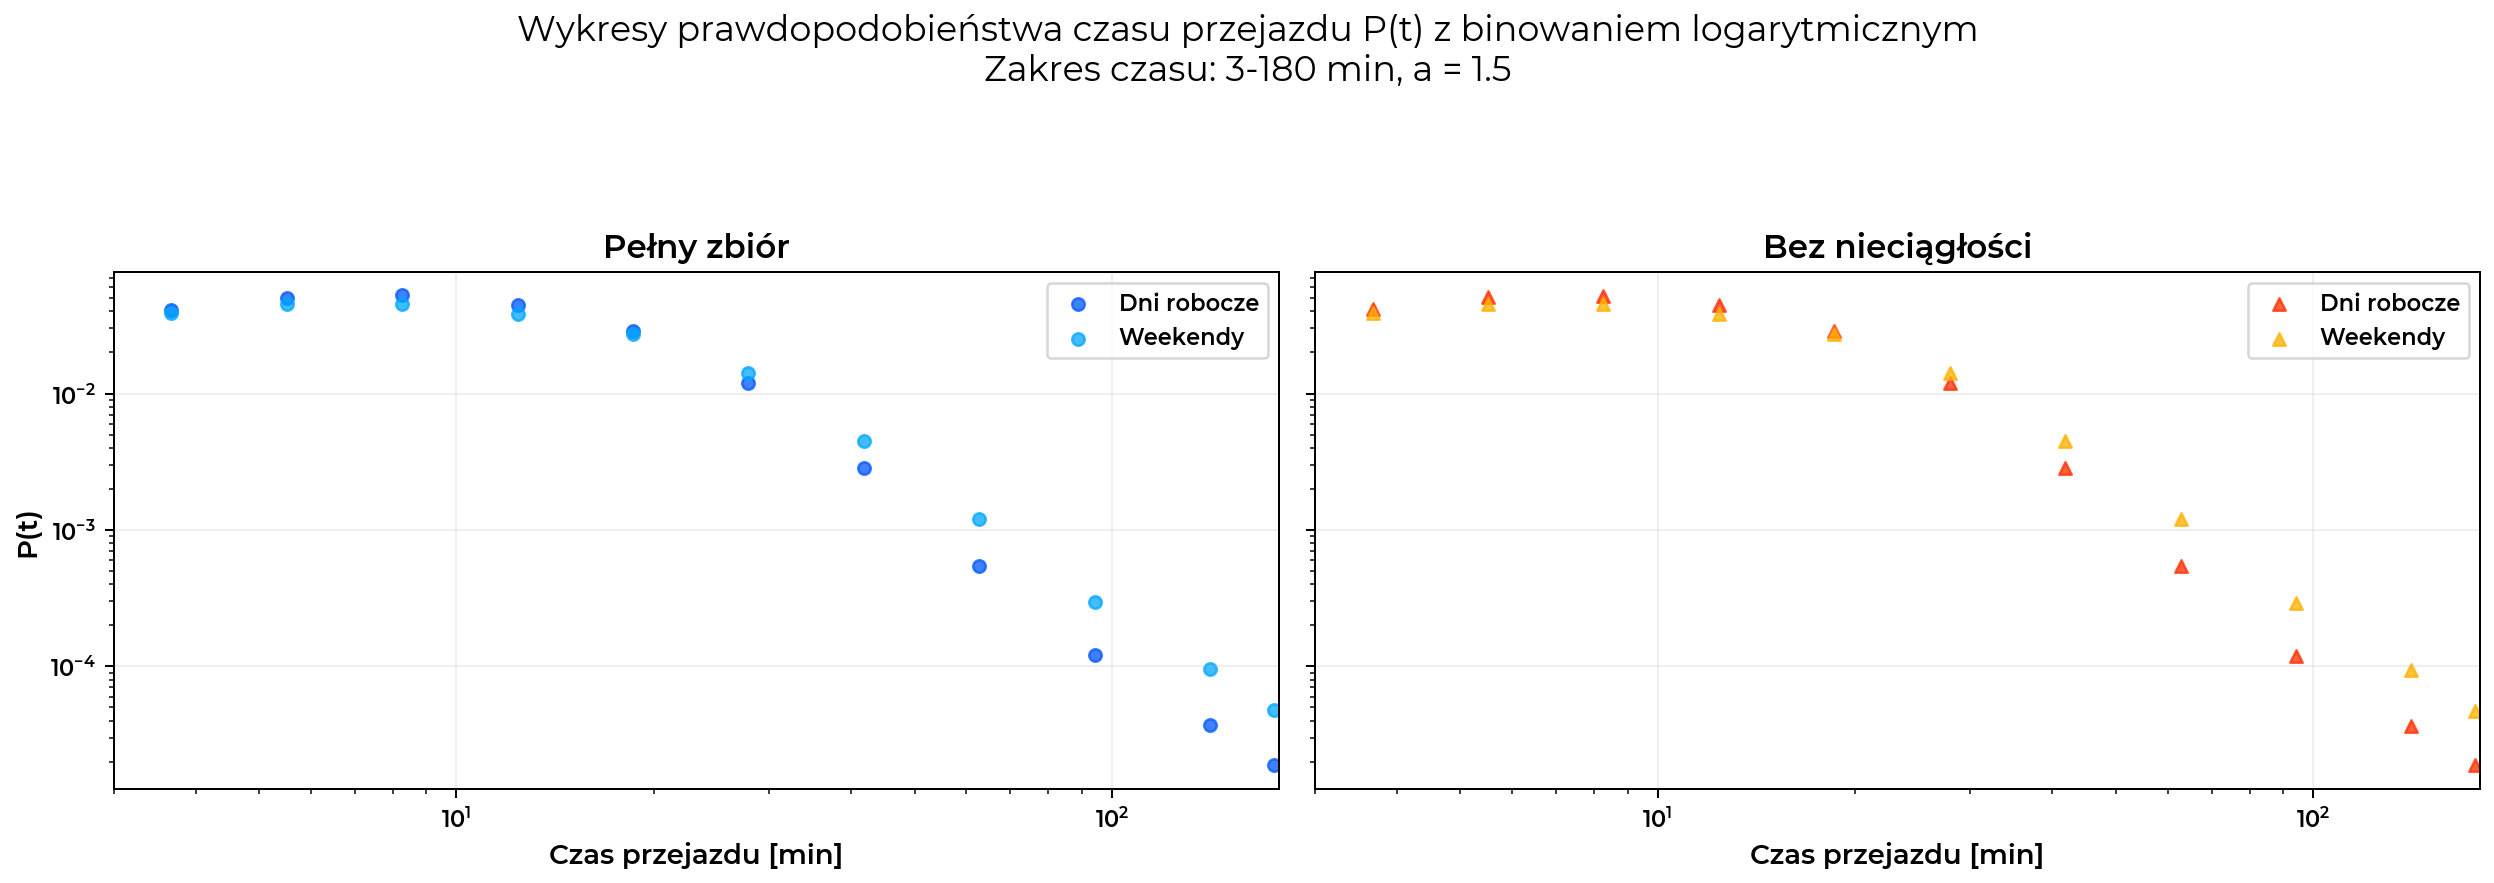

In [6]:
# ---------- Plotting logarithmic probability density ----------

fig, axes = dpu.plot_duration_log_probability_dataset_comparison(
    outputs_by_dataset,
    a_value=1.5,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)
plt.show()


Zakres dopasowania:
x_min = 15
x_max = 180

Dni robocze:
Nachylenie = -3.396
Wyraz wolny = 2.874

Weekendy:
Nachylenie = -2.936
Wyraz wolny = 2.307
Zakres dopasowania:
x_min = 15
x_max = 180

Dni robocze:
Nachylenie = -3.402
Wyraz wolny = 2.884

Weekendy:
Nachylenie = -2.947
Wyraz wolny = 2.324


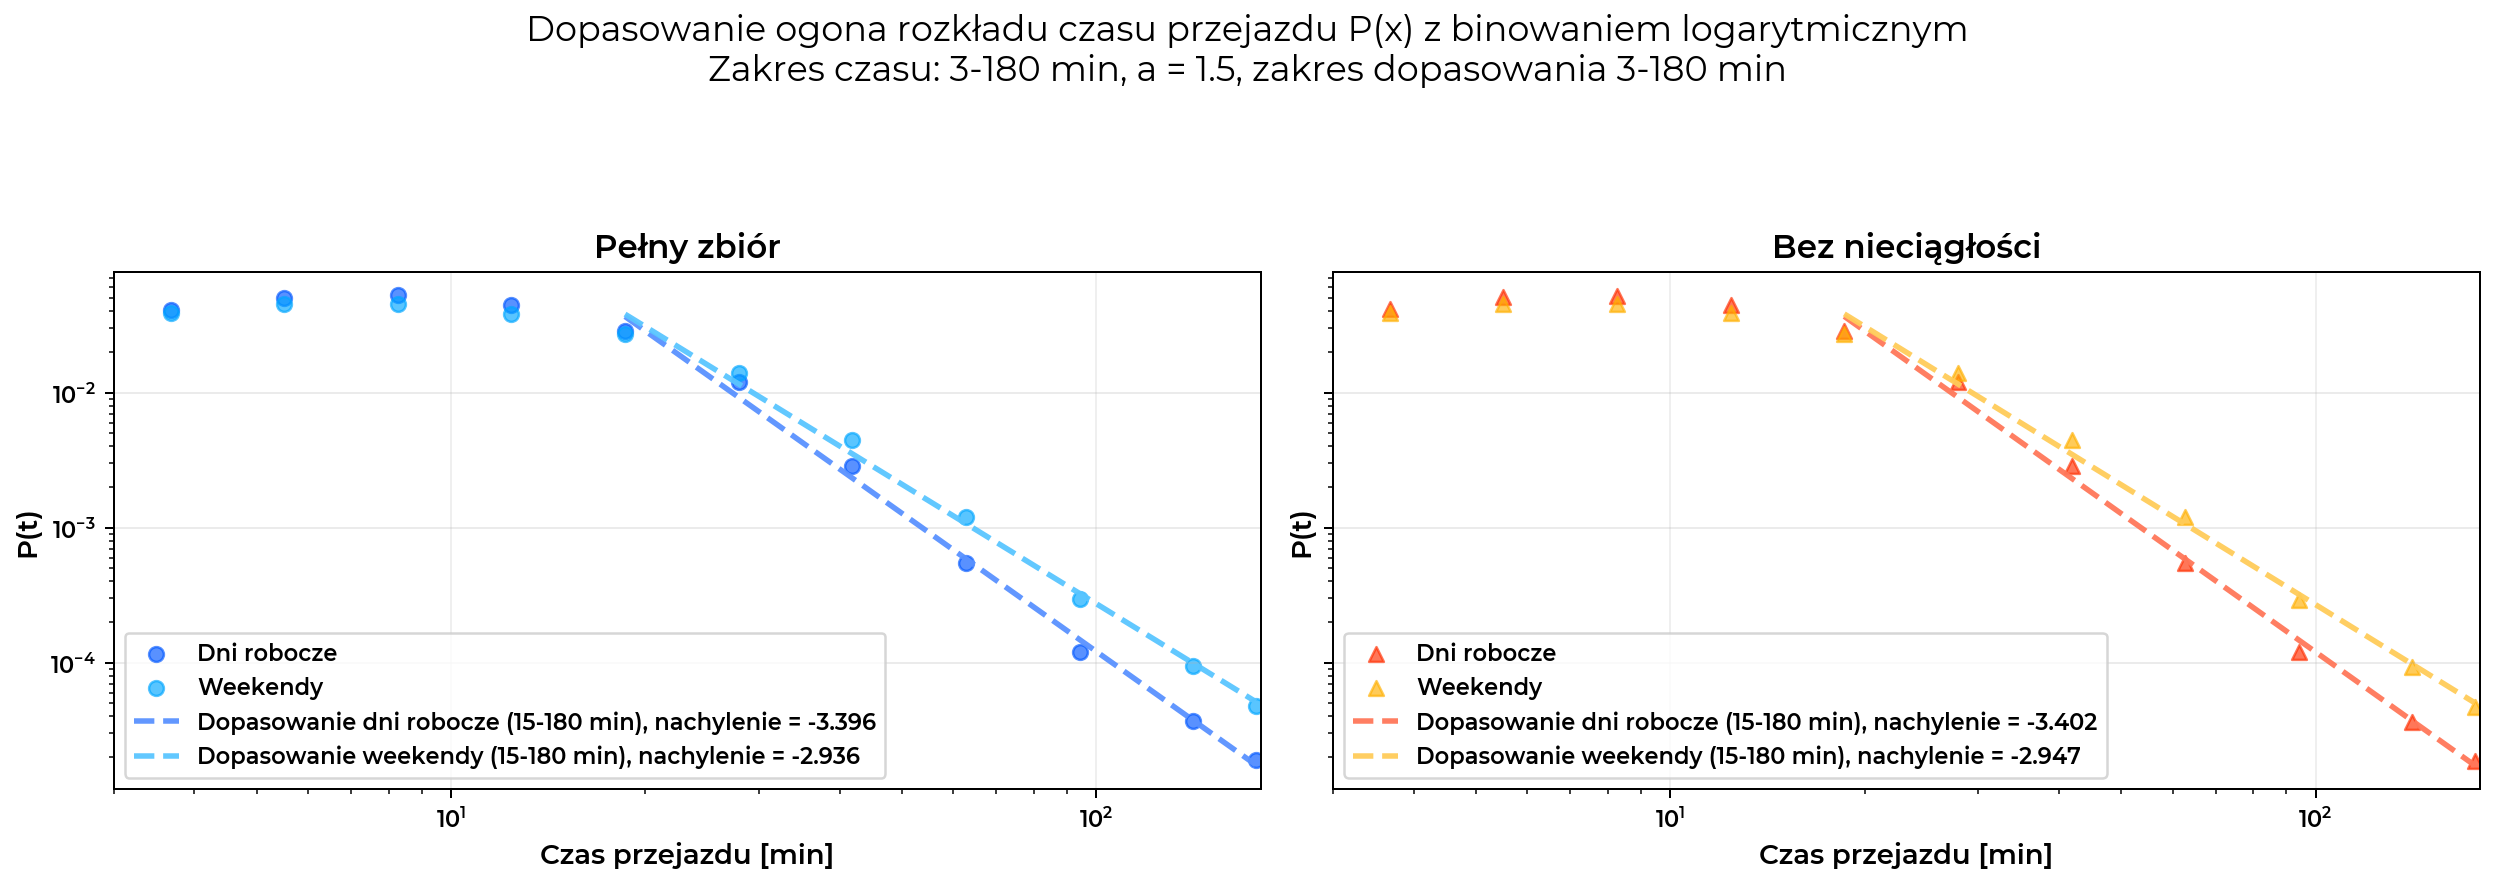

In [7]:
# ---------- Separate tail fits for weekdays and weekends ----------

tail_fits = {}
fig, axes = plt.subplots(
    1,
    len(outputs_by_dataset),
    figsize=(7 * len(outputs_by_dataset), 5),
    sharex=True,
    sharey=True,
)

if len(outputs_by_dataset) == 1:
    axes = [axes]

for ax, (dataset_name, outputs) in zip(axes, outputs_by_dataset.items()):
    tail_fits[dataset_name] = dpu.plot_duration_tail_fit(
        outputs["duration_results"],
        lower_limit=lower_limit,
        upper_limit=upper_limit,
        a_value=1.5,
        x_min=15,
        x_max=180,
        ax=ax,
        colors=dpu.dataset_day_type_colors(dataset_name),
        marker=dpu.dataset_marker(dataset_name),
    )
    ax.set_title(dataset_name)

fig.suptitle(
    "Dopasowanie ogona rozkładu czasu przejazdu P(x) z binowaniem logarytmicznym\n"
    f"Zakres czasu: {selected_duration_range_label}, a = 1.5, zakres dopasowania {lower_limit}-{upper_limit} min",
    fontsize=14,
)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()


# Histogram prędkości


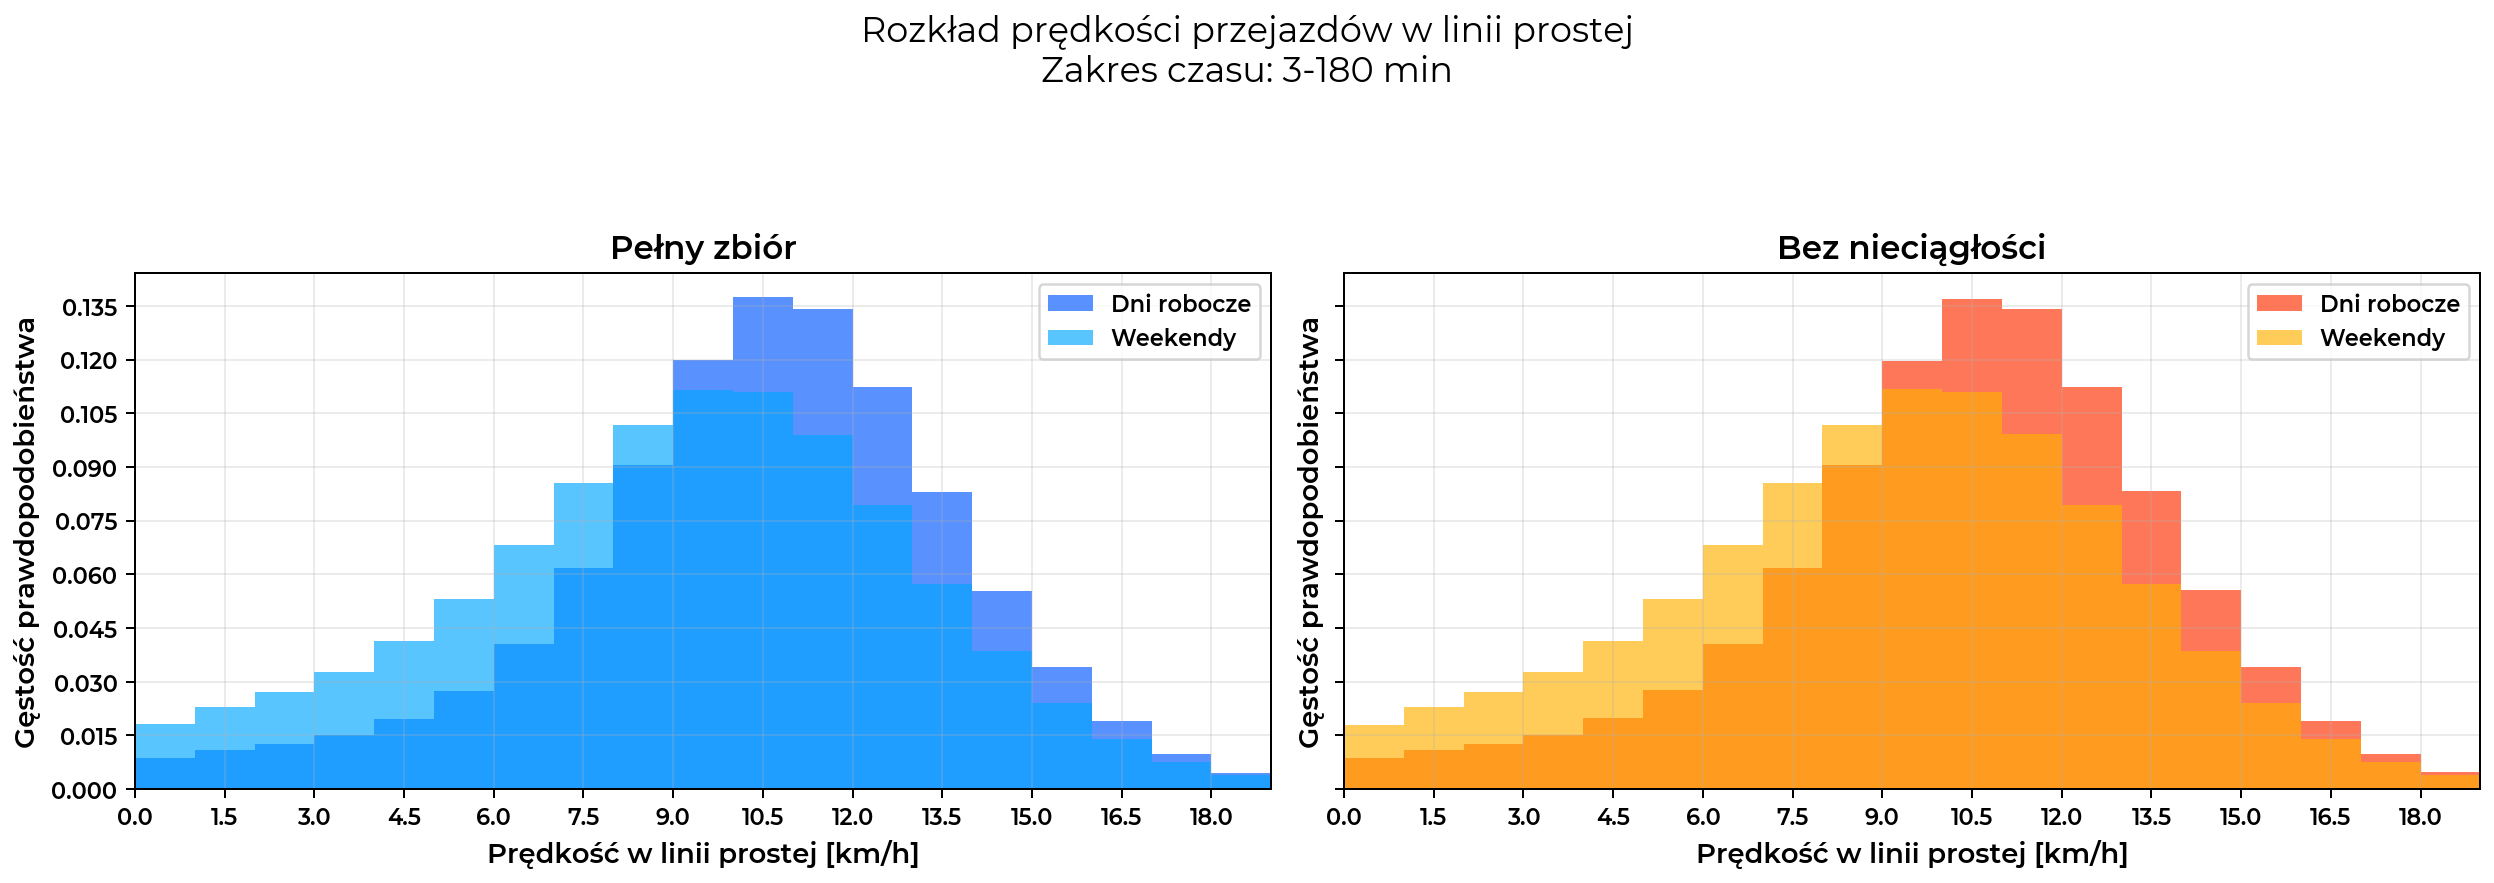

In [8]:
# ---------- Speed distribution for rides within the selected duration range ----------

fig, axes = dpu.plot_speed_histogram_dataset_comparison(
    outputs_by_dataset,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)
plt.show()


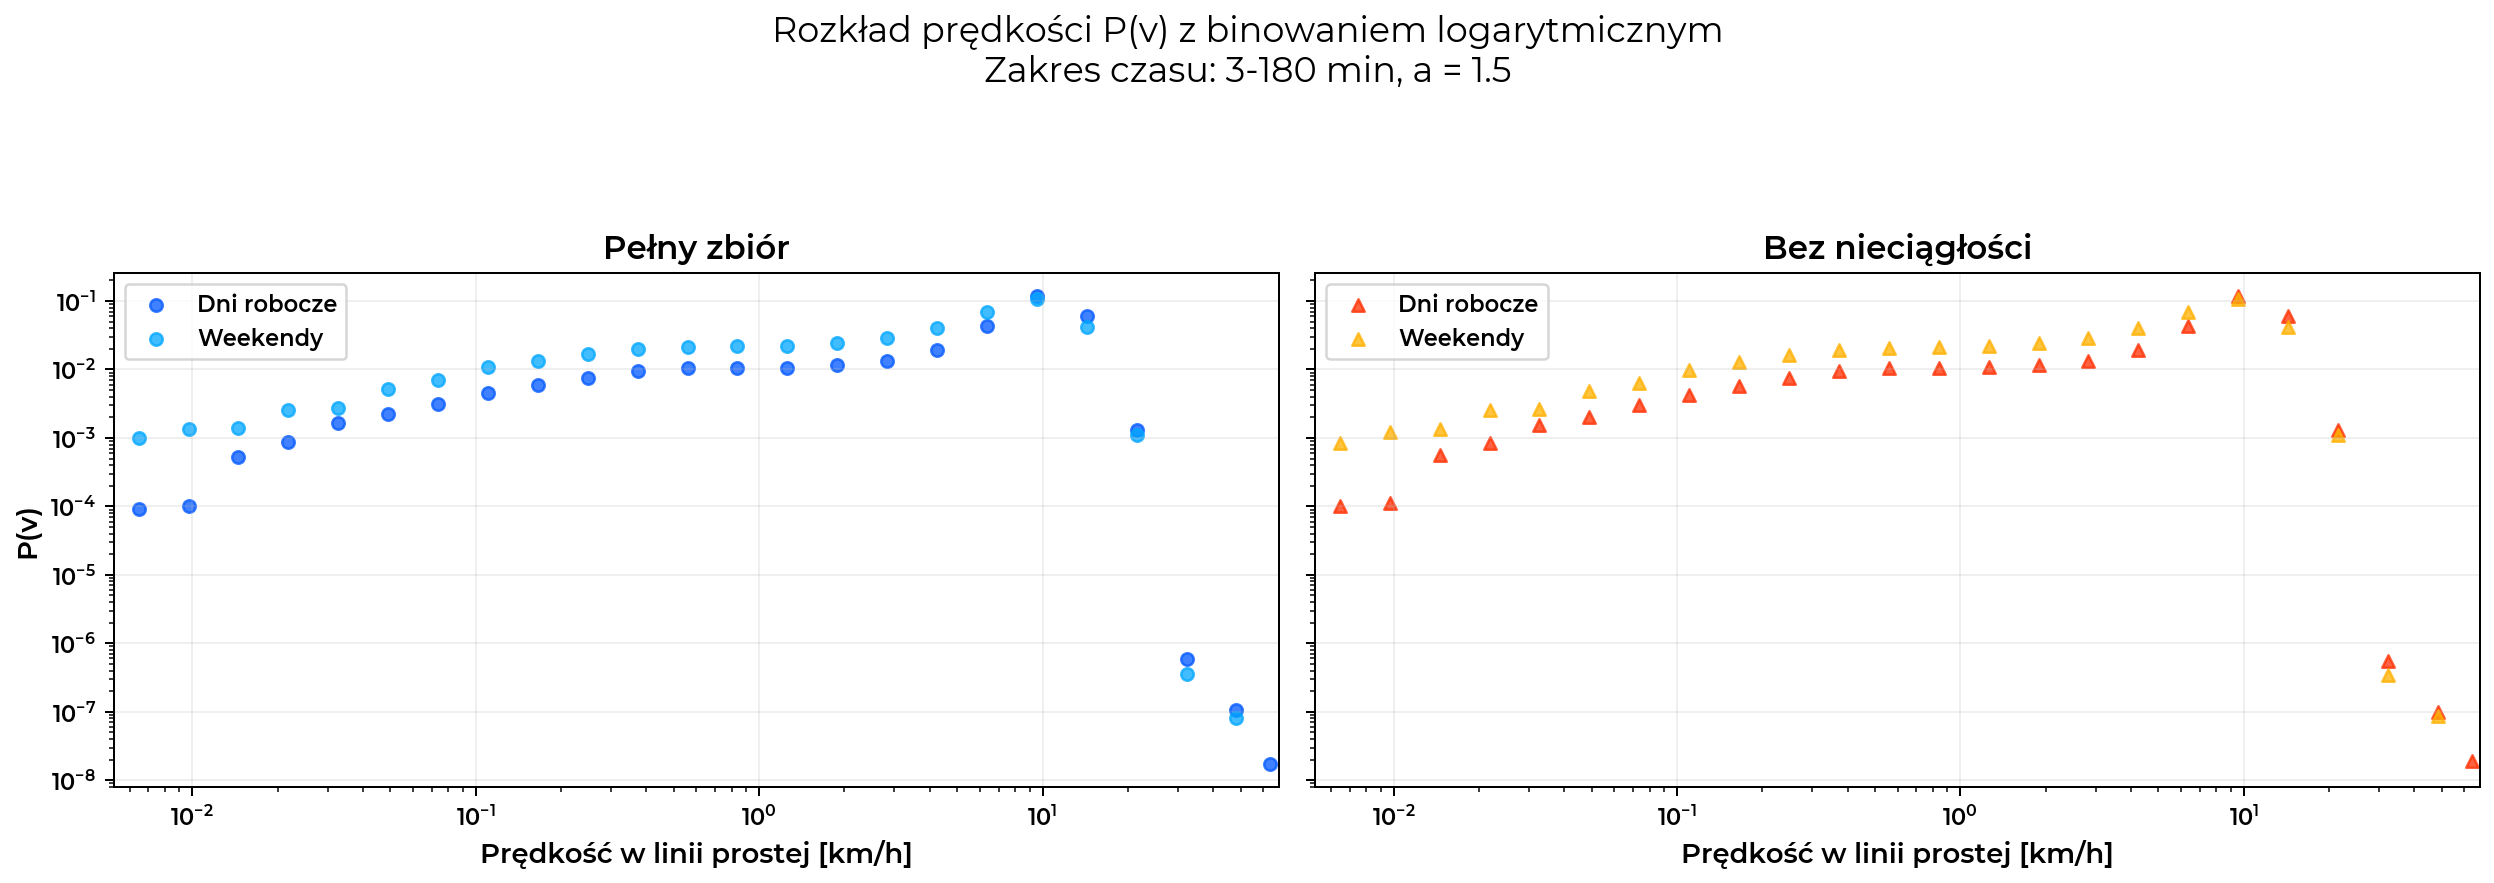

In [9]:
# ---------- Logarithmic speed distribution ----------

fig, axes = dpu.plot_speed_log_probability_dataset_comparison(
    outputs_by_dataset,
    a_value=1.5,
    range_label=selected_duration_range_label,
)
plt.show()


## ---------- Wykresy nałożone: zakres czasu 3-180 min ----------


Dopasowanie ogona na wykresie nałożonym:
Początek dopasowania: 20 min
Dni robocze: zakres binów 27.901-176.463 min, liczba punktów = 12, nachylenie = -3.535
Weekendy: zakres binów 27.901-176.463 min, liczba punktów = 12, nachylenie = -3.123


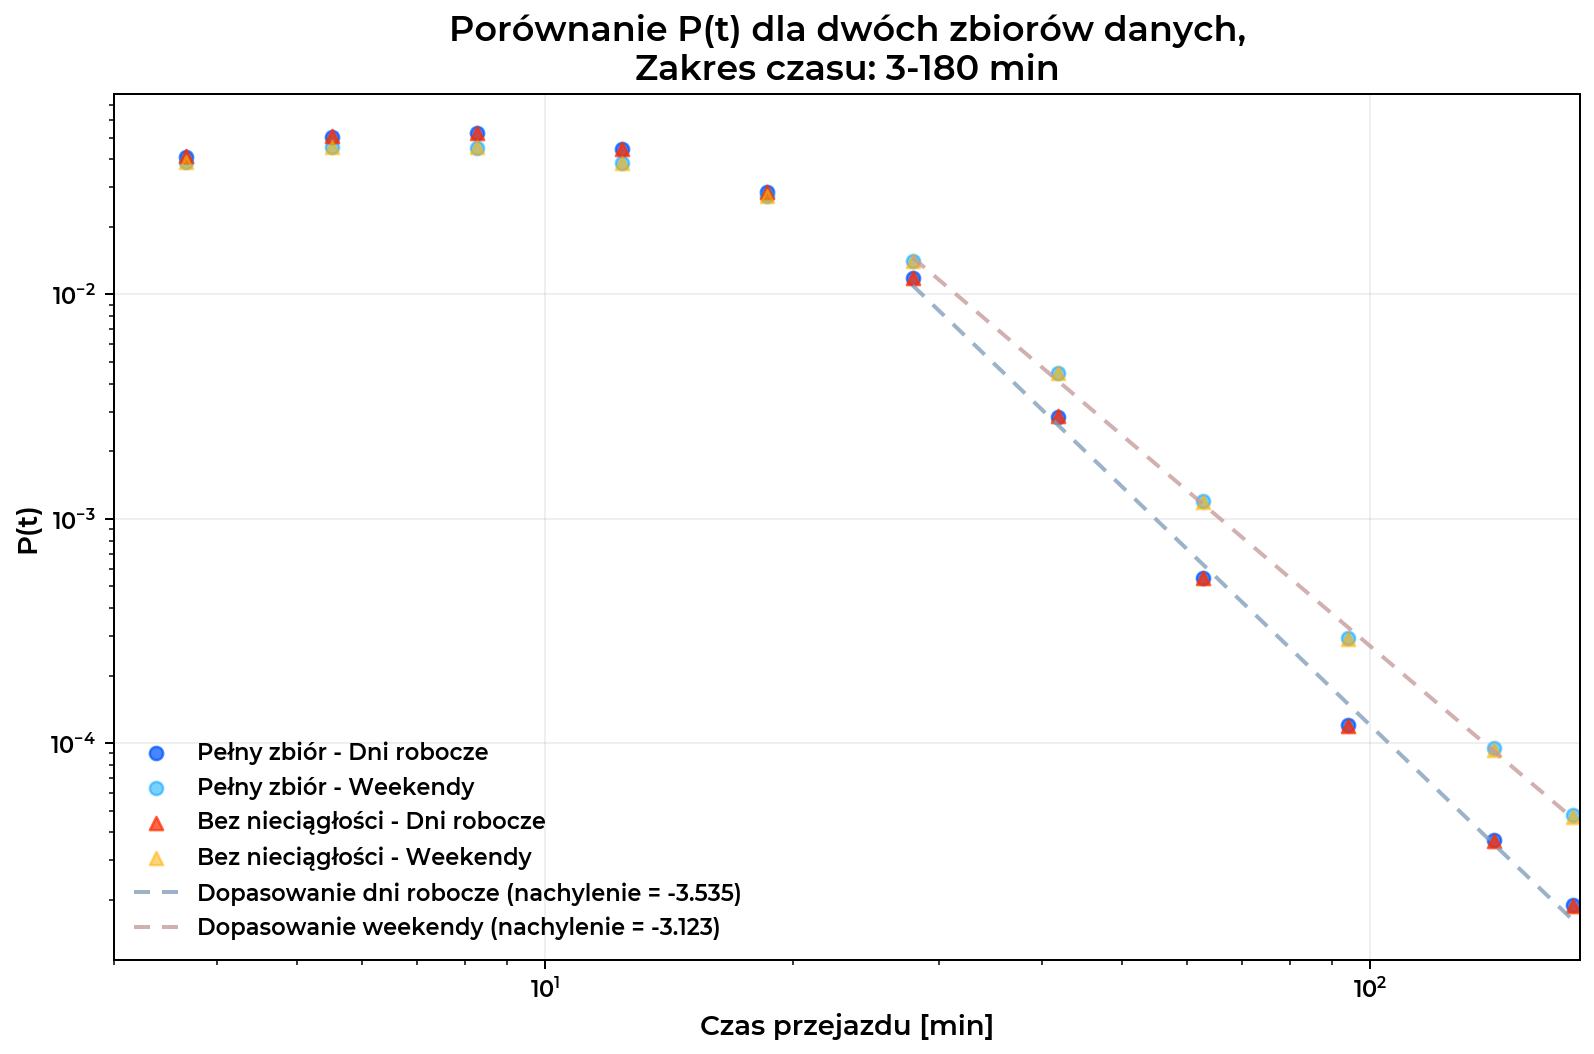

In [10]:
# ---------- Overlaid duration log-probability plots ----------

fig, ax = dpu.plot_duration_log_probability_dataset_overlay(
    outputs_by_dataset,
    a_value=1.5,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    range_label=selected_duration_range_label,
)

duration_overlay_tail_fit_min = 20
duration_overlay_tail_fit_max = upper_limit
duration_overlay_tail_fit_colors = {
    "weekdays": "#7F9DBA",
    "weekends": "#C79A9A",
}
duration_overlay_day_labels = {
    "weekdays": "dni robocze",
    "weekends": "weekendy",
}
duration_overlay_tail_fits = {}

for day_type in ["weekdays", "weekends"]:
    x_tail_parts = []
    p_tail_parts = []

    for outputs in outputs_by_dataset.values():
        duration_values = outputs["duration_results"][1.5][day_type]
        x_values = duration_values["x"]
        p_values = duration_values["p"]
        fit_mask = (
            (x_values > 0)
            & (p_values > 0)
            & (x_values >= duration_overlay_tail_fit_min)
            & (x_values <= duration_overlay_tail_fit_max)
        )

        x_tail_parts.append(x_values[fit_mask])
        p_tail_parts.append(p_values[fit_mask])

    x_tail_data = np.concatenate(x_tail_parts)
    p_tail_data = np.concatenate(p_tail_parts)

    if len(x_tail_data) < 2:
        raise ValueError(f"Za mało punktów do dopasowania: {duration_overlay_day_labels[day_type]}")

    tail_slope, tail_intercept = np.polyfit(
        np.log10(x_tail_data),
        np.log10(p_tail_data),
        1,
    )
    x_tail_fit = np.logspace(
        np.log10(x_tail_data.min()),
        np.log10(x_tail_data.max()),
        200,
    )
    p_tail_fit = 10**tail_intercept * x_tail_fit**tail_slope

    ax.plot(
        x_tail_fit,
        p_tail_fit,
        color=duration_overlay_tail_fit_colors[day_type],
        linestyle=(0, (4, 3)),
        linewidth=1.6,
        alpha=0.78,
        zorder=3,
        label=(
            f"Dopasowanie {duration_overlay_day_labels[day_type]} "
            f"(nachylenie = {tail_slope:.3f})"
        ),
    )

    duration_overlay_tail_fits[day_type] = {
        "slope": tail_slope,
        "intercept": tail_intercept,
        "x_fit": x_tail_fit,
        "p_fit": p_tail_fit,
        "x_data": x_tail_data,
        "p_data": p_tail_data,
    }

ax.legend(frameon=False, fontsize=9)

print("Dopasowanie ogona na wykresie nałożonym:")
print(f"Początek dopasowania: {duration_overlay_tail_fit_min:g} min")
for day_type, fit in duration_overlay_tail_fits.items():
    print(
        f"{duration_overlay_day_labels[day_type].capitalize()}: "
        f"zakres binów {fit['x_data'].min():.3f}-{fit['x_data'].max():.3f} min, "
        f"liczba punktów = {len(fit['x_data'])}, "
        f"nachylenie = {fit['slope']:.3f}"
    )

plt.show()


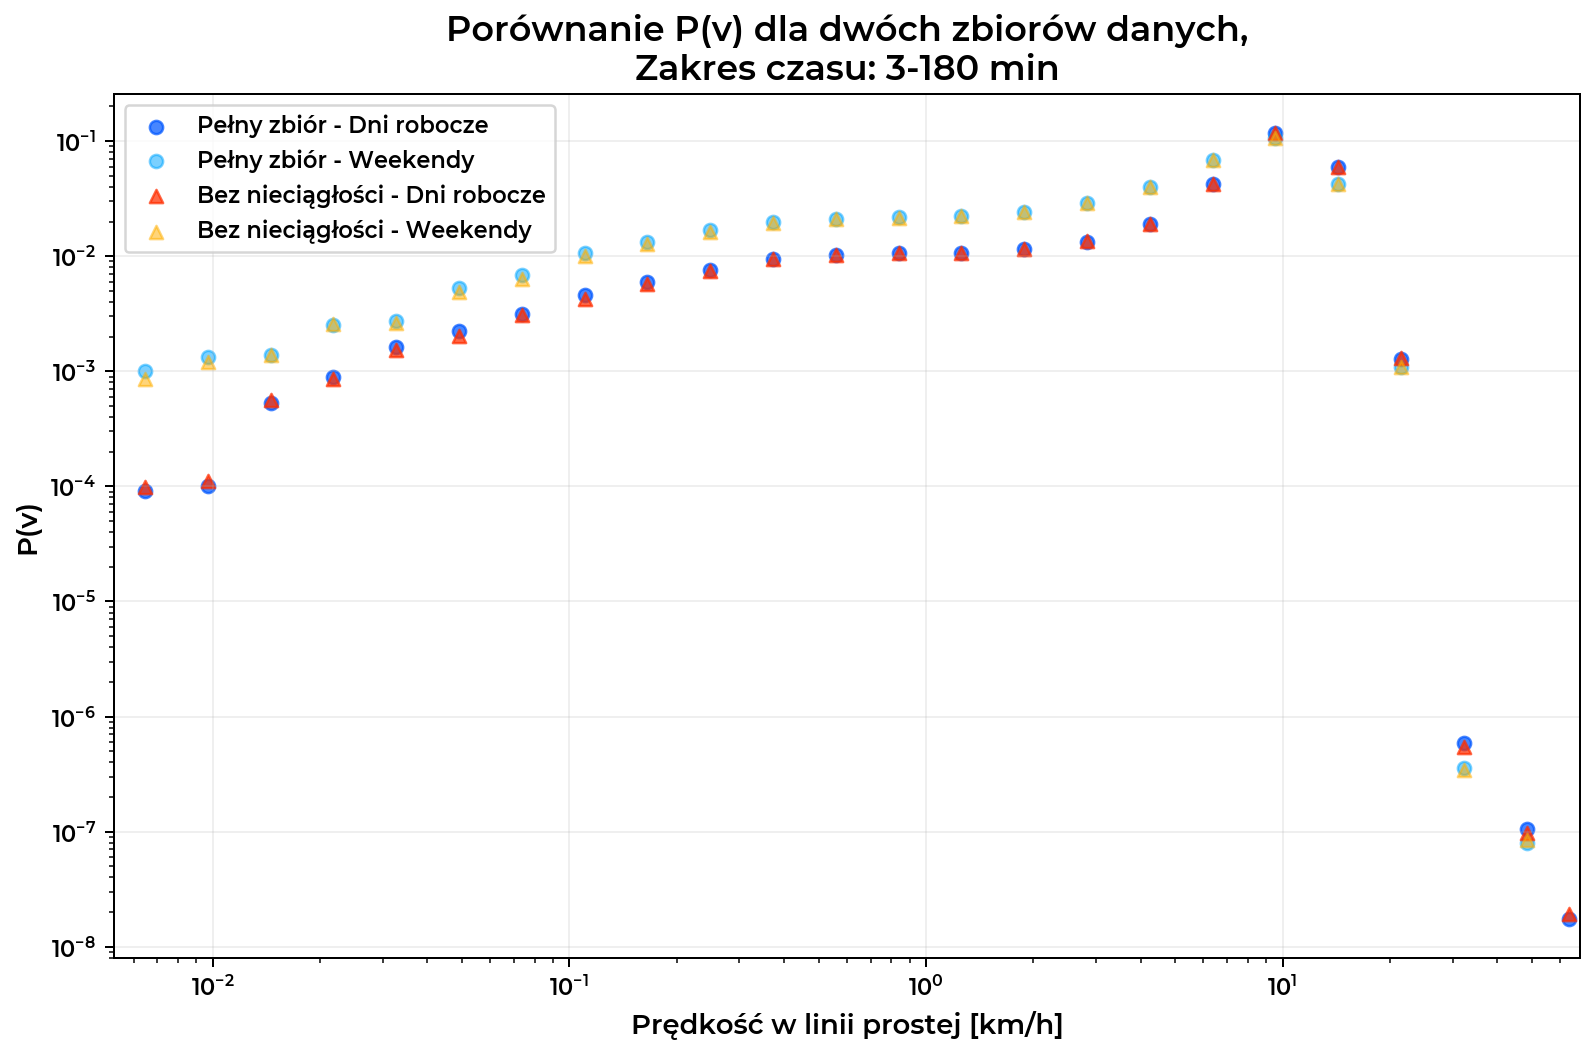

In [11]:
# ---------- Overlaid speed log-probability plots ----------

fig, ax = dpu.plot_speed_log_probability_dataset_overlay(
    outputs_by_dataset,
    a_value=1.5,
    range_label=selected_duration_range_label,
)
plt.show()


## ---------- Para 2: pełny zakres czasu ----------


In [12]:
# ---------- Preparing duration results for the full positive time range ----------

full_range_limits = []

for dataset_name, outputs in outputs_by_dataset.items():
    duration_values = outputs["dur_dist_data"]["total_duration_minutes"]
    positive_duration_values = duration_values[
        duration_values.notna()
        & np.isfinite(duration_values)
        & (duration_values > 0)
    ]

    full_range_limits.append(
        (positive_duration_values.min(), positive_duration_values.max())
    )

full_lower_limit = min(limit[0] for limit in full_range_limits)
full_upper_limit = max(limit[1] for limit in full_range_limits)

print(f"Pełny dodatni zakres czasu: {full_lower_limit:.6f}-{full_upper_limit:.2f} min")

full_range_outputs_by_dataset = {}

for dataset_name, outputs in outputs_by_dataset.items():
    dur_dist_data_weekdays = outputs["dur_dist_data_weekdays"]
    dur_dist_data_weekends = outputs["dur_dist_data_weekends"]

    duration_counts_weekdays, duration_counts_weekends = dpu.count_rides_by_duration(
        dur_dist_data_weekdays,
        dur_dist_data_weekends,
        lower_limit=full_lower_limit,
        upper_limit=full_upper_limit,
    )

    duration_weekdays, duration_weekends = dpu.prepare_duration_data(
        dur_dist_data_weekdays,
        dur_dist_data_weekends,
        lower_limit=full_lower_limit,
        upper_limit=full_upper_limit,
    )

    duration_results = dpu.calculate_duration_log_binning_results(
        duration_weekdays,
        duration_weekends,
        lower_limit=full_lower_limit,
        upper_limit=full_upper_limit,
        a_values=a_values,
    )

    full_range_outputs_by_dataset[dataset_name] = {
        **outputs,
        "duration_counts_weekdays": duration_counts_weekdays,
        "duration_counts_weekends": duration_counts_weekends,
        "duration_weekdays": duration_weekdays,
        "duration_weekends": duration_weekends,
        "duration_results": duration_results,
    }


Pełny dodatni zakres czasu: 0.003267-272120.61 min

a = 1.5
Number of bins: 45
First bin edges: [0.00326667 0.0049     0.00735    0.011025   0.0165375 ]
Last bin edges: [ 54180.92837261  81271.39255891 121907.08883836 182860.63325755
 272120.61363333]

a = 1.75
Number of bins: 33
First bin edges: [0.00326667 0.00571667 0.01000417 0.01750729 0.03063776]
Last bin edges: [ 36492.88788627  63862.55380098 111759.46915171 195579.0710155
 272120.61363333]

a = 2
Number of bins: 27
First bin edges: [0.00326667 0.00653333 0.01306667 0.02613333 0.05226667]
Last bin edges: [ 27402.78613333  54805.57226667 109611.14453333 219222.28906667
 272120.61363333]

a = 1.5
Number of bins: 45
First bin edges: [0.00326667 0.0049     0.00735    0.011025   0.0165375 ]
Last bin edges: [ 54180.92837261  81271.39255891 121907.08883836 182860.63325755
 272120.61363333]

a = 1.75
Number of bins: 33
First bin edges: [0.00326667 0.00571667 0.01000417 0.01750729 0.03063776]
Last bin edges: [ 36492.88788627  63862.5538

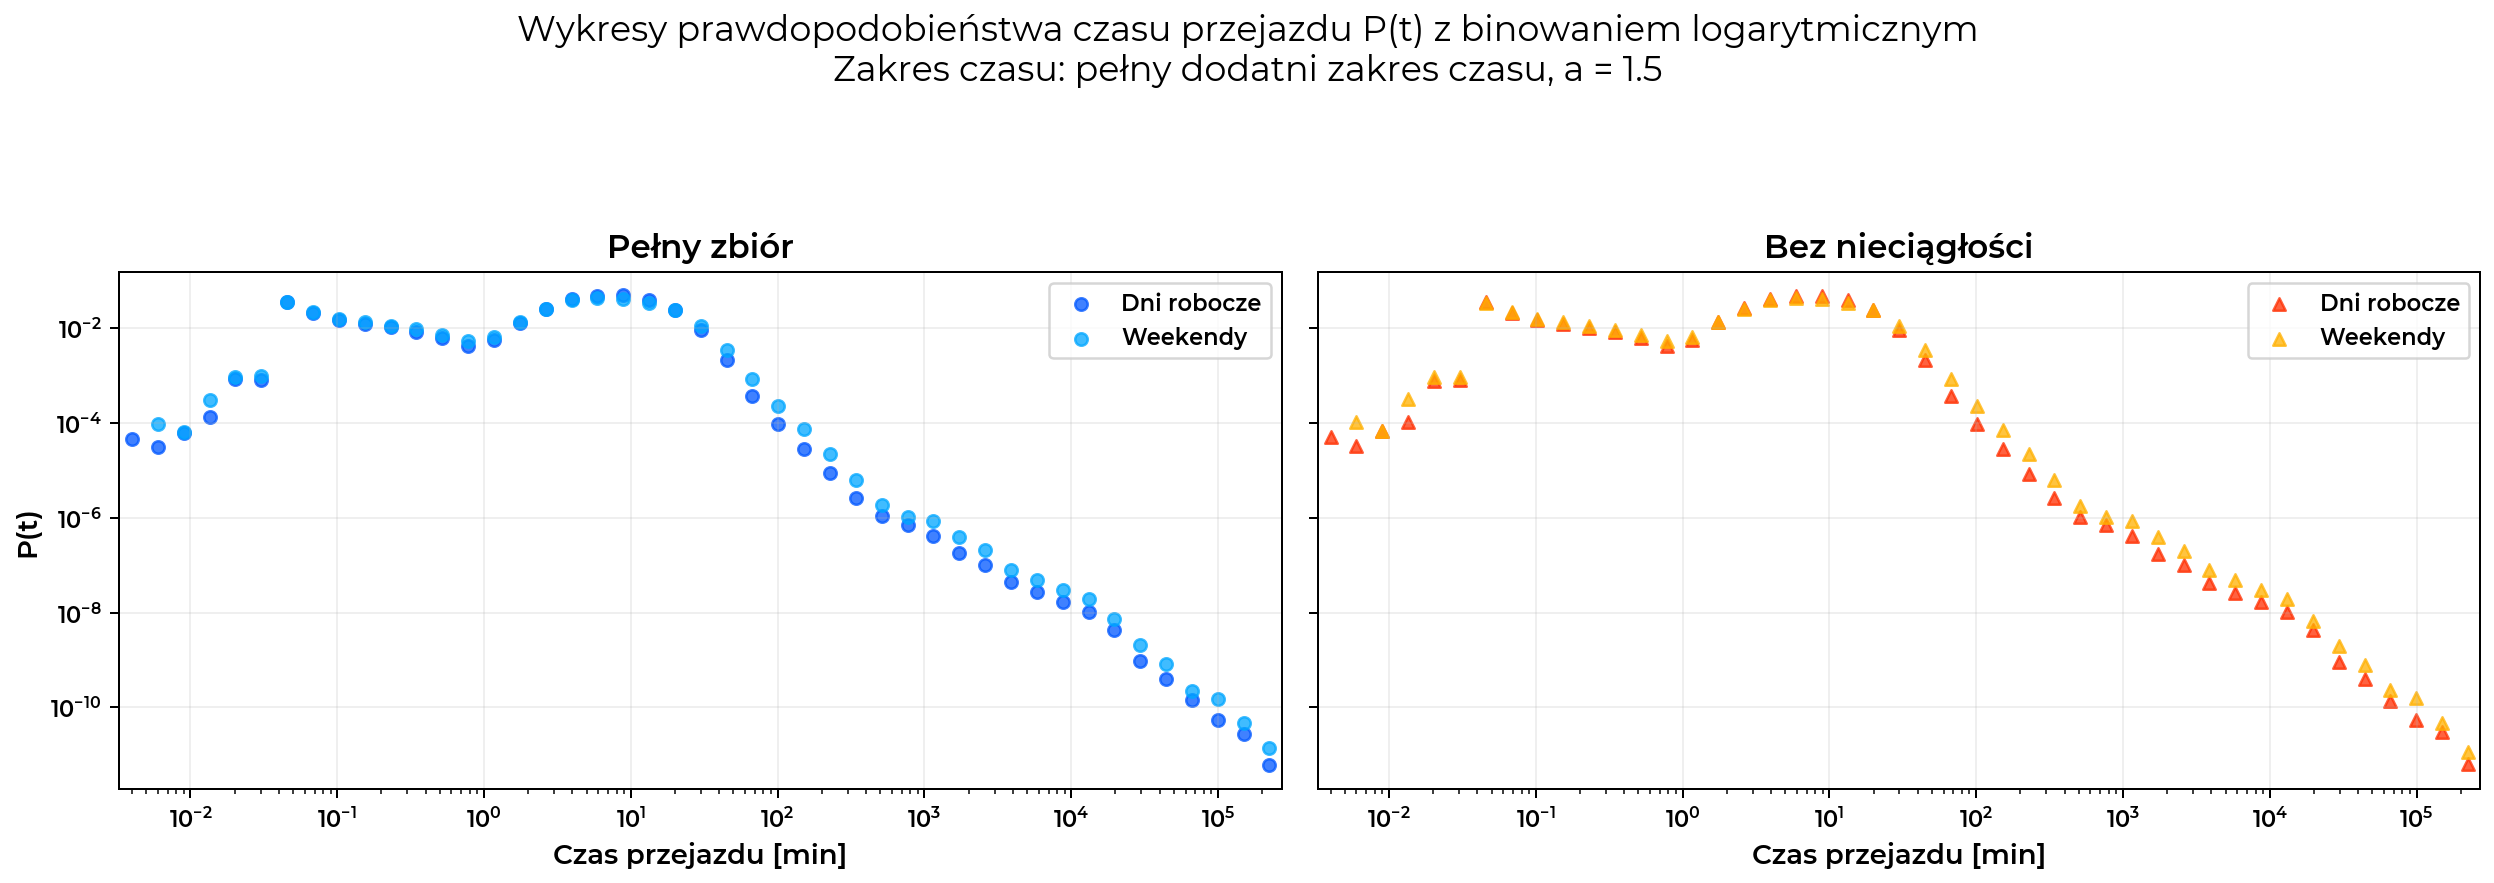

In [13]:
# ---------- Full-range duration log-probability comparison ----------

fig, axes = dpu.plot_duration_log_probability_dataset_comparison(
    full_range_outputs_by_dataset,
    a_value=1.5,
    lower_limit=full_lower_limit,
    upper_limit=full_upper_limit,
    range_label=full_duration_range_label,
)
plt.show()


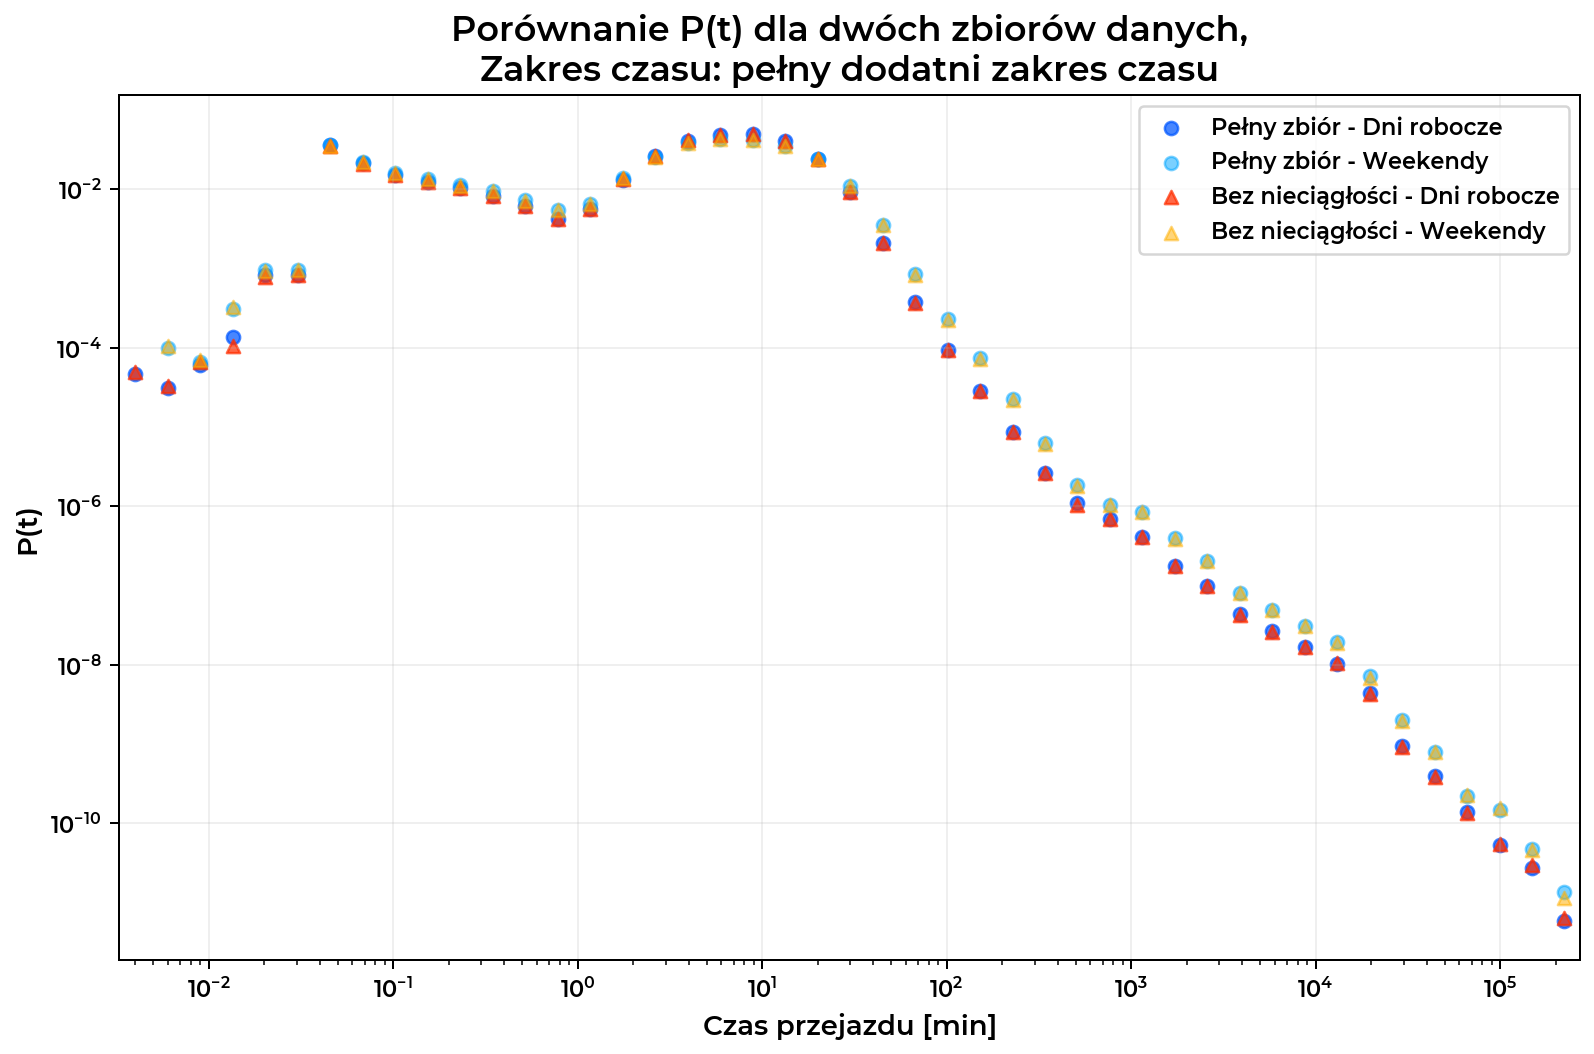

In [14]:
# ---------- Full-range overlaid duration log-probability comparison ----------

fig, ax = dpu.plot_duration_log_probability_dataset_overlay(
    full_range_outputs_by_dataset,
    a_value=1.5,
    lower_limit=full_lower_limit,
    upper_limit=full_upper_limit,
    range_label=full_duration_range_label,
)
plt.show()
